**Recurrent** **Neural** **Network** (**RNN**)

A Recurrent Neural Network (RNN) is a class of artificial neural network
designed to process sequential data. Unlike traditional feedforward
networks, RNNs contain feedback loops that allow information to
persist. This internal "memory" enables them to analyze time-series
data, text, and audio by retaining context from previous steps in a
sequence

**Limitations** **of** **RNN**

While effective for short-term memory, traditional "vanilla"
RNNs struggle with long-term dependencies due to the
vanishing gradient problem, where gradients shrink
exponentially over many time steps. To mitigate this,
advanced variations like LSTMs (Long Short-Term Memory)
and GRUs (Gated Recurrent Units) are frequently used to
selectively remember or forget information over longer
sequences

**Long** **Short**-**Term** **Memory** (**LSTM**)


Long Short-Term Memory
(LSTM) is a specialized type of
Recurrent Neural Network
(RNN) designed to remember
information over long data
sequences. It solves the
vanishing gradient problem of
standard RNNs using three core
mechanisms: the forget gate,
the input gate, and the output
gate

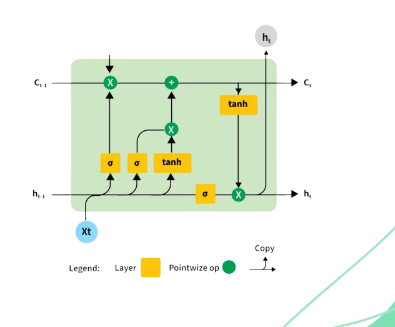

**Core** **Architecture** **and** **Gates**

**Forget** **Gate**: Decides what old information to throw
away from the cell state.

**Input** **Gate**: Determines what new information to add
to the cell state.

**Output** **Gate**: Controls what information is passed on
as the next hidden state/output.

**Cell** **State**: Acts as a conveyor belt passing long-term
memory straight down the chain with minor linear
interactions

**Common** **Uses**

Time-Series Forecasting: Predicting stock prices or
weather patterns.

Natural Language Processing: Speech recognition
and early machine translation models.

Healthcare: Tracking patient vitals and predicting
disease progression over tim

**ANN** (**Feedforward** **Neural** **Network**] **Drawback**

Cannot process sequential data effectively

No memory of previous inputs

Cannot capture temporal dependencies

Unsuitable for variable-length input sequences

Poor performance in NLP and speech tasks

Processes each input independently

Not ideal for time-series forecasting



**Why** **RNN** **is** **Better**

RNNs are designed for sequence and time-series data.

RNNs have hidden states that retain information from
previous time steps.

RNNs learn relationships between past and current inputs.

RNNs can process sequences of different lengths.

RNNs excel in language modeling, speech recognition,
and text generation.

RNNs process inputs sequentially, considering context.

RNNs are specifically developed for forecasting
sequential data.

In [1]:
# Jenna Climate LSTM FOrecasting(TensorFLow/Keras)
import tensorflow as tf

In [2]:
print("Tensorflow", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

Tensorflow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from zipfile import ZipFile
import pandas as pd
import matplotlib.pyplot as plt
import keras

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"


13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
df = pd.read_csv(csv_path)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
# Use temperature as target
series = df['T (degC)'].values.reshape(-1,1)
series.shape

(420551, 1)

In [6]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
series  = scalar.fit_transform(series)
series

array([[0.24863161],
       [0.24216288],
       [0.24050423],
       ...,
       [0.329242  ],
       [0.31149444],
       [0.30170841]])

In [7]:
import numpy as np
TIME_STEPS = 72
X = []
y = []
for i in range(len(series)-TIME_STEPS):
  X.append(series[i:i+TIME_STEPS])
  y.append(series[i+TIME_STEPS])
X = np.array(X)
y = np.array(y)


In [8]:
n = len(X)
train = int(n*0.7)
val = int(n*0.9)
x_train, y_train = X[:train], y[:train]
x_val, y_val = X[train:val], y[train:val]
x_test, y_test = X[val:], y[val:]

In [9]:
print(x_train.shape, x_val.shape, x_test.shape)

(294335, 72, 1) (84096, 72, 1) (42048, 72, 1)


In [10]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
lstm_model = Sequential([
    LSTM(16, input_shape = x_train.shape[-2:]),
    Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
lstm_model.compile(optimizer="adam", loss="mae")

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
checkpoint = ModelCheckpoint(
    "best_jena_lstm.keras",
    monitor = "val_loss",
    save_best_only = True,
    verbose=1
)

In [15]:
early = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True
)

In [16]:
history = lstm_model.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = 20,
    batch_size = 256,
    callbacks = [checkpoint, early],
    verbose = 1

)

Epoch 1/20
1148/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0353
Epoch 1: val_loss improved from None to 0.00497, saving model to best_jena_lstm.keras

Epoch 1: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0126 - val_loss: 0.0050
Epoch 2/20
1148/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045
Epoch 2: val_loss improved from 0.00497 to 0.00349, saving model to best_jena_lstm.keras

Epoch 2: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 3/20
1145/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037
Epoch 3: val_loss improved from 0.00349 to 0.00312, saving model to best_jena_lstm.keras

Epoch 3: finished saving model to best_jena_lstm.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 4/20
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032
Epoch 4: val_loss improved from 0.00312 to 0.00270, saving 

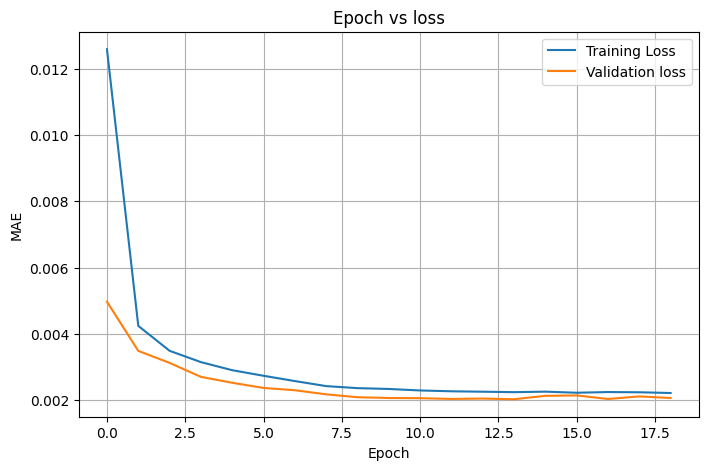

In [18]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation loss")
plt.title('Epoch vs loss')
plt.xlabel('Epoch')
plt.ylabel('MAE'),
plt.grid(True)
plt.legend()
plt.show()

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
MAE: 0.13401232348755146
RMSE: 0.20867280688100298


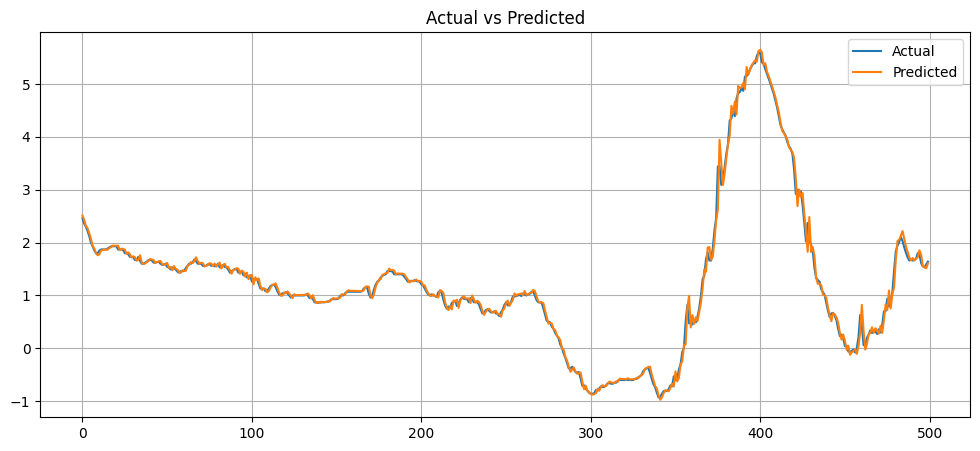

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np # Import numpy for np.sqrt

model=load_model('best_jena_lstm.keras')

pred=model.predict(x_test)

pred=scalar.inverse_transform(pred)
actual=scalar.inverse_transform(y_test)

mae=mean_absolute_error(actual,pred)
rmse=np.sqrt(mean_squared_error(actual,pred))

print('MAE:',mae)
print('RMSE:',rmse)

plt.figure(figsize=(12,5))
plt.plot(actual[:500],label='Actual')
plt.plot(pred[:500],label='Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
last =series[-TIME_STEPS:].reshape(1,TIME_STEPS,1)
next_temp = scalar.inverse_transform(model.predict(last))
print("Next Prediction:", next_temp[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Next Prediction: -5.014705


# data chainhcha

# data preprocessing  (missing value, normalization, EDA)
# after geeting clean data
# data split (train,test , val)
#  model ma pathauni
#  model evaluaion
#  model prediction